In [10]:
# Query 0: Question: Load the dataset and review its size and booking status distribution.

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('uber__1_.xlsx', sheet_name='Sheet1')

print("Total Records:", len(df))

print("\nBooking Status Distribution:")
print(df['Booking Status'].value_counts())

Total Records: 150000

Booking Status Distribution:
Booking Status
Completed                93000
Cancelled by Driver      27000
Cancelled by Customer    10500
No Driver Found          10500
Incomplete                9000
Name: count, dtype: int64


In [11]:
# Query 1: Question: Clean the dataset and validate key columns before performing analysis.

# Convert Booking Value to numeric
df['Booking Value'] = pd.to_numeric(df['Booking Value'], errors='coerce')

# Convert Date to proper format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Check missing values
print("\n=== NULL VALUES ===")
print(df.isnull().sum())

# Check data types
print("\n=== DATA TYPES ===")
print(df.dtypes)

# Check date range
print("\n=== DATE RANGE ===")
print(df['Date'].min(), "to", df['Date'].max())

# Note:
# Missing values are expected because:
# - Booking Value exists only for completed rides
# - Cancellation-related columns exist only for cancelled rides


=== NULL VALUES ===
Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

=== DATA TYPES ===
Date                                 datetime64[ns]
Time                                         object
Bookin

In [12]:
# Query 2: Question: Prepare the dataset by creating time-based features and filtering completed rides.

# Create features
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce').dt.hour
df['Month'] = df['Date'].dt.month

# Filter completed rides
completed = df[df['Booking Status'] == 'Completed'].copy()

# Validate cleaned dataset
print("\n=== COMPLETED DATA NULL CHECK ===")
print(completed.isnull().sum())

# Note:
# SQL analysis uses all bookings
# Python analysis focuses only on completed rides for revenue-related analysis


=== COMPLETED DATA NULL CHECK ===
Date                                     0
Time                                     0
Booking ID                               0
Booking Status                           0
Customer ID                              0
Vehicle Type                             0
Pickup Location                          0
Drop Location                            0
Cancelled Rides by Customer          93000
Reason for cancelling by Customer    93000
Cancelled Rides by Driver            93000
Driver Cancellation Reason           93000
Incomplete Rides                     93000
Incomplete Rides Reason              93000
Booking Value                            0
Ride Distance                            0
Driver Ratings                           0
Customer Rating                          0
Payment Method                           0
Hour                                     0
Month                                    0
dtype: int64


In [13]:
# Query 3: Question: Analyze customer retention to understand repeat usage behavior over time.

completed_copy = completed.copy()

# Create cohort
completed_copy['OrderMonth'] = completed_copy['Date'].dt.to_period('M')

first_order = completed_copy.groupby('Customer ID')['Date'].min().reset_index()
first_order.columns = ['Customer ID', 'FirstOrderDate']
first_order['CohortMonth'] = first_order['FirstOrderDate'].dt.to_period('M')

completed_copy = completed_copy.merge(first_order[['Customer ID', 'CohortMonth']], on='Customer ID')

# Cohort index
completed_copy['CohortIndex'] = (completed_copy['OrderMonth'] - completed_copy['CohortMonth']).apply(lambda x: x.n)

# Pivot table
cohort_data = completed_copy.groupby(['CohortMonth', 'CohortIndex'])['Customer ID'].nunique().reset_index()

cohort_pivot = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='Customer ID')

print("\n=== COHORT TABLE ===")
print(cohort_pivot.head())

# Retention rate
cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0) * 100

print("\n=== RETENTION RATE (%) ===")
print(retention_matrix.round(2))


=== COHORT TABLE ===
CohortIndex      0      1      2      3      4      5      6      7      8   \
CohortMonth                                                                   
2025-01      7902.0  480.0  560.0  566.0  538.0  542.0  562.0  521.0  526.0   
2025-02      6399.0  427.0  406.0  407.0  436.0  471.0  439.0  407.0  451.0   
2025-03      6682.0  413.0  435.0  437.0  465.0  430.0  412.0  441.0  450.0   
2025-04      5987.0  378.0  411.0  386.0  380.0  400.0  368.0  404.0  395.0   
2025-05      5840.0  382.0  357.0  362.0  328.0  385.0  349.0  425.0    NaN   

CohortIndex     9      10     11  
CohortMonth                       
2025-01      533.0  555.0  500.0  
2025-02      433.0  446.0    NaN  
2025-03      458.0    NaN    NaN  
2025-04        NaN    NaN    NaN  
2025-05        NaN    NaN    NaN  

=== RETENTION RATE (%) ===
CohortIndex     0     1     2     3     4     5     6     7     8     9   \
CohortMonth                                                                

In [14]:
# Query 4: Question: Segment customers based on number of rides and evaluate their revenue contribution.

customer_summary = completed.groupby('Customer ID').agg({
    'Booking Value': ['sum', 'count']
}).reset_index()

customer_summary.columns = ['Customer ID', 'Total_Revenue', 'Num_Rides']

# Segmentation logic
def segment_customer(rides):
    if rides == 1:
        return 'One-time'
    elif rides <= 5:
        return 'Occasional'
    elif rides <= 15:
        return 'Regular'
    else:
        return 'VIP'

customer_summary['Segment'] = customer_summary['Num_Rides'].apply(segment_customer)

segment_summary = customer_summary.groupby('Segment').agg({
    'Customer ID': 'count',
    'Total_Revenue': 'sum'
})

print("\n=== CUSTOMER SEGMENTATION ===")
print(segment_summary)

# Ride distribution (important for explanation)
print("\n=== RIDE DISTRIBUTION ===")
print(customer_summary['Num_Rides'].value_counts().sort_index().head(10))


=== CUSTOMER SEGMENTATION ===
            Customer ID  Total_Revenue
Segment                               
Occasional        16988     22989660.0
One-time          47581     24246832.0
Regular               6        24082.0

=== RIDE DISTRIBUTION ===
Num_Rides
1    47581
2     5650
3    11278
4       51
5        9
6        6
Name: count, dtype: int64


In [15]:
# Query 5: Question: Validate that segmentation results match overall dataset totals.

total_customers = customer_summary['Customer ID'].nunique()
total_revenue = customer_summary['Total_Revenue'].sum()
expected_revenue = completed['Booking Value'].sum()

print("\n=== VALIDATION CHECK ===")
print("Total customers:", total_customers)
print("Segmented revenue:", total_revenue)
print("Actual revenue:", expected_revenue)
print("Difference:", total_revenue - expected_revenue)


=== VALIDATION CHECK ===
Total customers: 64575
Segmented revenue: 47260574.0
Actual revenue: 47260574.0
Difference: 0.0


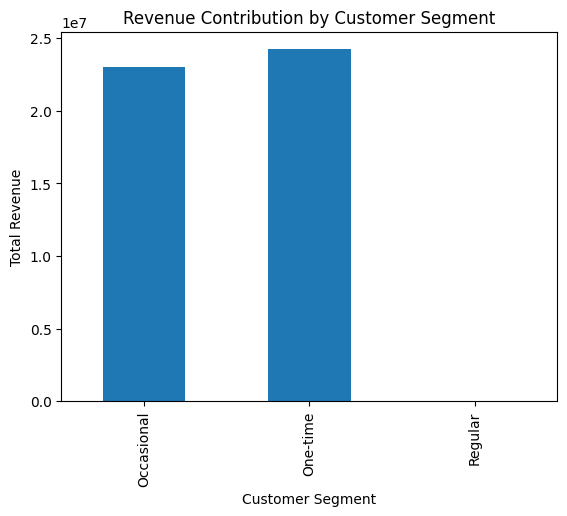

In [16]:
# Query 6: Question: Visualize revenue contribution across customer segments.

segment_summary['Total_Revenue'].plot(kind='bar')
plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")
plt.show()

<Figure size 1000x600 with 0 Axes>

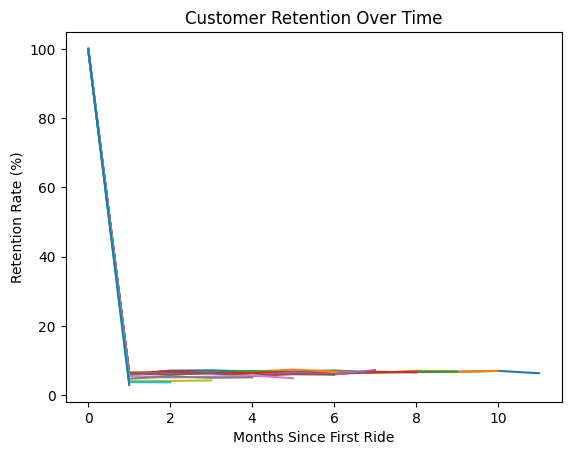

In [17]:
# Query 7: Question: Visualize how customer retention changes over time after first ride.

plt.figure(figsize=(10,6))

retention_matrix.T.plot(legend=False)

plt.title("Customer Retention Over Time")
plt.xlabel("Months Since First Ride")
plt.ylabel("Retention Rate (%)")

plt.show()

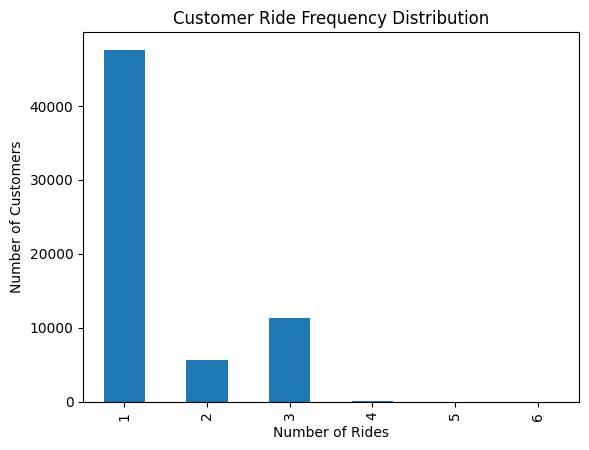

In [18]:
# Query 8: Question: Visualize how frequently customers use the service.

customer_summary['Num_Rides'].value_counts().sort_index().head(10).plot(kind='bar')

plt.title("Customer Ride Frequency Distribution")
plt.xlabel("Number of Rides")
plt.ylabel("Number of Customers")

plt.show()